In [ ]:
#Install Kaggle
!pip install kaggle --quiet

In [ ]:
#Upload Kaggle.Json File
from google.colab import files
files.upload()

{}

In [ ]:
#Create the Kaggle Directory
!mkdir ~/.kaggle

In [ ]:
#Copy the Kagge.json file
!cp kaggle.json ~/.kaggle/

cp: cannot stat 'kaggle.json': No such file or directory


In [ ]:
!chmod 600 /root/.kaggle/kaggle.json

chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
#Download the dataset
!kaggle datasets download -d 'aditya126/basic-maths-symbols-dataset' -p ../data/MathSymbols

Dataset URL: https://www.kaggle.com/datasets/aditya126/basic-maths-symbols-dataset
License(s): ODbL-1.0
100% 54.9M/54.9M [00:00<00:00, 67.8MB/s]



In [ ]:
#Unzip the dataset
!unzip ../data/MathSymbols/basic-maths-symbols-dataset.zip -d ../data/MathSymbols/

Streaming output truncated to the last 5000 lines.
  inflating: ../data/MathSymbols/symbol_dataset/times/times_3248.png  
  inflating: ../data/MathSymbols/symbol_dataset/times/times_3249.png  
  inflating: ../data/MathSymbols/symbol_dataset/times/times_325.png  
  inflating: ../data/MathSymbols/symbol_dataset/times/times_3250.png  
  inflating: ../data/MathSymbols/symbol_dataset/times/times_3251.png  
  inflating: ../data/MathSymbols/symbol_dataset/times/times_3252.png  
  inflating: ../data/MathSymbols/symbol_dataset/times/times_3253.png  
  inflating: ../data/MathSymbols/symbol_dataset/times/times_3254.png  
  inflating: ../data/MathSymbols/symbol_dataset/times/times_3255.png  
  inflating: ../data/MathSymbols/symbol_dataset/times/times_3256.png  
  inflating: ../data/MathSymbols/symbol_dataset/times/times_3257.png  
  inflating: ../data/MathSymbols/symbol_dataset/times/times_3258.png  
  inflating: ../data/MathSymbols/symbol_dataset/times/times_3259.png  
  inflating: ../data/MathSy

In [ ]:
!ls -ltr ../data/MathSymbols/

total 56216
-rw-r--r--  1 root root 57553393 Feb 10  2025 basic-maths-symbols-dataset.zip
drwxr-xr-x 10 root root     4096 Mar 28 06:15 symbol_dataset


In [ ]:
!chmod 777 ../data/MathSymbols/basic-maths-symbols-dataset.zip

In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Path to dataset root (adjust if needed)
DATASET_PATH = "../data/MathSymbols/symbol_dataset"

# Map folder names to symbols
label_map = {
    "plus": "+",
    "minus": "-",
    "multiply": "*",
    "divide": "/",
    "equals": "=",
    "times": "x",
    "open_bracket": "(",
    "close_bracket": ")"
}

# Allowed classes (exclude brackets)
allowed_classes = ["+", "-", "*", "/", "=", "x"]

IMG_SIZE = 28
X, y = [], []

# Loop through folders
for folder, symbol in label_map.items():
    if symbol not in allowed_classes:
        continue  # skip brackets

    folder_path = os.path.join(DATASET_PATH, folder)
    for img_file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_file)

        # Read grayscale image
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        # Resize (just to be safe)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        # Normalize
        img = img / 255.0

        X.append(img)
        y.append(allowed_classes.index(symbol))

# Convert to numpy arrays
X = np.array(X).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
y = np.array(y)

# One-hot encode labels
y = to_categorical(y, num_classes=len(allowed_classes))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Classes:", allowed_classes)

Training set shape: (36000, 28, 28, 1)
Test set shape: (9000, 28, 28, 1)
Classes: ['+', '-', '*', '/', '=', 'x']


In [ ]:
np.save("/content/X.npy", X)
np.save("/content/y.npy", y)

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(6, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=15,
    batch_size=32
)

Epoch 1/15
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9825 - loss: 0.0491 - val_accuracy: 1.0000 - val_loss: 1.0693e-04
Epoch 2/15
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 1.0000 - loss: 5.2964e-05 - val_accuracy: 1.0000 - val_loss: 1.8199e-05
Epoch 3/15
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 1.0000 - loss: 1.2240e-05 - val_accuracy: 1.0000 - val_loss: 7.3176e-06
Epoch 4/15
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 1.0000 - loss: 4.9056e-06 - val_accuracy: 1.0000 - val_loss: 3.7123e-06
Epoch 5/15
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 1.0000 - loss: 1.8650e-06 - val_accuracy: 1.0000 - val_loss: 1.5894e-06
Epoch 6/15
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 1.0000 - loss: 1.1355e-06 - val_accuracy: 1.0000 - val_loss: 1.0858e-06
Epoch 7/15
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9993 - loss: 0.0039 - val_accuracy: 1.0000 - val_loss: 5.4774e-04
Epoch 8/15
1125/1125 ━━━━━━━━━━━━━━━━━━━━

In [ ]:
model.save("symbol_model.keras")

282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


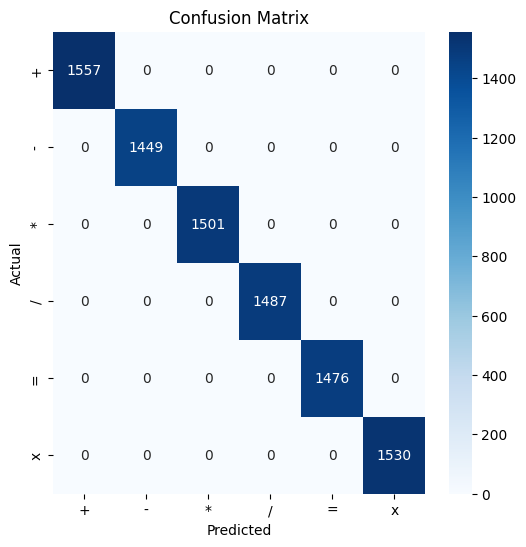

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Predict
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['+', '-', '*', '/', '=', 'x'],
            yticklabels=['+', '-', '*', '/', '=', 'x'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

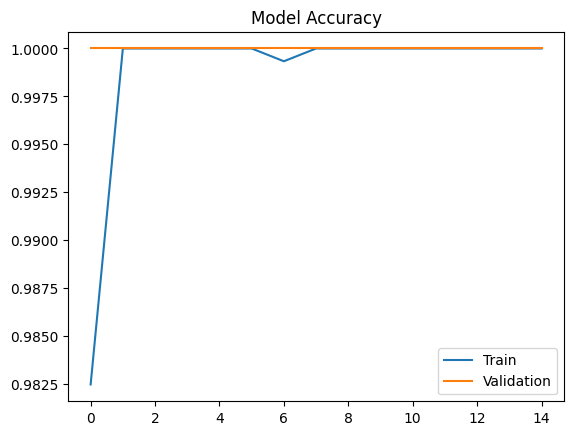

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title("Model Accuracy")
plt.show()

In [ ]:
print(os.listdir("/content"))

['.config', 'y.npy', 'symbol_model.keras', 'X.npy', 'sample_data']


In [ ]:
from google.colab import files
files.download("symbol_model.keras")
files.download("X.npy")
files.download("y.npy")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Digits_model training

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Reshape and normalize
x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Build CNN model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train
early_stop = EarlyStopping(monitor='val_accuracy', patience=2, restore_best_weights=True)
model.fit(x_train, y_train, epochs=15, batch_size=128,
          validation_data=(x_test, y_test),
          callbacks=[early_stop])

# Evaluate
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {acc:.4f}")

# Save model
model.save("mnist_digit_model.keras")
print("Model saved as mnist_digit_model.keras")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9434 - loss: 0.1922 - val_accuracy: 0.9828 - val_loss: 0.0546
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9835 - loss: 0.0543 - val_accuracy: 0.9833 - val_loss: 0.0491
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9888 - loss: 0.0375 - val_accuracy: 0.9890 - val_loss: 0.0302
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9911 - loss: 0.0289 - val_accuracy: 0.9893 - val_loss: 0.0317
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9929 - loss: 0.0220 - val_accuracy: 0.9906 - val_loss: 0.0293
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9941 - loss: 0.0182 - val_accuracy: 0.9922 - val_loss: 0.0249
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9957 - loss: 0.0140 - val_accuracy: 0.9896 - val_loss: 0.0322
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9960 - loss: 0.0126 - val_accuracy: 0

In [ ]:
from google.colab import files
files.download("mnist_digit_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>